## Task 6 - Cluster Evaluation Against Ground Truth

This task evaluates the performance of K-Means, GMM, and Hierarchical Clustering
by comparing their cluster assignments against the binarised clinical diagnosis
using the Adjusted Rand Index (ARI) and confusion matrices.

This task connects the unsupervised clustering results from Tasks 3-5 with the
ground truth labels that were set aside in Task 2, providing a quantitative
assessment of how well the geometric structure discovered by each algorithm
aligns with clinical reality.

**Pipeline for this task:**
1. Load and binarise the target variable (0 = no disease, 1-4 = disease present)
2. Refit all three clustering algorithms with k=2
3. Compute Adjusted Rand Index (ARI) for each method
4. Generate confusion matrices showing cluster-to-label mappings
5. Analyze cluster purity and inter-method agreement
6. Visualise results and provide clinical interpretation

> **Important:** Unsupervised methods optimise geometric structure, NOT class
> separation. Low ARI does not mean the method failed - it means the natural
> geometric clusters don't perfectly match clinical diagnosis. Heart disease is
> clinically heterogeneous - not all patients present with the same profile.

### 6.1 - Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)

# Visual theme matching Tasks 3-5
PALETTE = ['#4A90D9', '#E8603C', '#2EAF7D', '#9B59B6', '#F39C12', '#C0392B', '#1ABC9C']
PALETTE_SEQ = 'YlOrRd'
PALETTE_DIV = 'coolwarm'

sns.set_theme(
    style='whitegrid', palette=PALETTE, font='DejaVu Sans', font_scale=1.1,
    rc={
        'figure.dpi': 120, 'figure.figsize': (10, 5),
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.titleweight': 'bold', 'axes.titlesize': 13,
        'axes.labelsize': 11, 'xtick.labelsize': 9,
        'ytick.labelsize': 9, 'legend.frameon': False, 'legend.fontsize': 9,
    }
)
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=PALETTE)
print('Libraries loaded successfully.')

Libraries loaded successfully.


### 6.2 - Load Data & Binarise Target

In [2]:
# Load clustering matrix and ground truth labels
X_cluster = pd.read_csv('X_cluster.csv')
y_raw     = pd.read_csv('y_clean.csv').squeeze()

# Binarise target: 0 = no disease, 1-4 = disease present
y_true = (y_raw > 0).astype(int)

print(f'Clustering matrix shape: {X_cluster.shape}')
print(f'Target shape           : {y_true.shape}')
print(f'\nBinarised target distribution:')
print(f'  No disease (0): {(y_true == 0).sum()} patients ({(y_true == 0).sum()/len(y_true)*100:.1f}%)')
print(f'  Disease (1)   : {(y_true == 1).sum()} patients ({(y_true == 1).sum()/len(y_true)*100:.1f}%)')

Clustering matrix shape: (297, 15)
Target shape           : (297,)

Binarised target distribution:
  No disease (0): 160 patients (53.9%)
  Disease (1)   : 137 patients (46.1%)


### 6.3 - Refit Clustering Algorithms

We refit each algorithm with k=2 (the optimal choice from Tasks 3-5)
using the same parameters to ensure reproducibility.

**K-Means:** Hard clustering with spherical cluster assumption, minimises
within-cluster sum of squared distances.

**GMM:** Soft probabilistic clustering with full covariance matrices, can
capture elliptical cluster shapes.

**Hierarchical Clustering (Ward linkage):** Agglomerative method that minimises
within-cluster variance, similar objective to K-Means but builds a dendrogram.

In [3]:
print('='*70)
print('REFITTING CLUSTERING ALGORITHMS')
print('='*70)

# ── K-Means ────────────────────────────────────────────────────────────────
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=20,
    random_state=42
)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'\nK-Means cluster sizes:')
unique, counts = np.unique(kmeans_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} patients ({n/len(kmeans_labels)*100:.1f}%)')

# ── Gaussian Mixture Model ─────────────────────────────────────────────────
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    n_init=10,
    random_state=42,
    max_iter=200
)
gmm.fit(X_cluster)
gmm_labels = gmm.predict(X_cluster)
print(f'\nGMM cluster sizes:')
unique, counts = np.unique(gmm_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} patients ({n/len(gmm_labels)*100:.1f}%)')

# ── Hierarchical Clustering (Ward linkage) ─────────────────────────────────
# Ward linkage minimises within-cluster variance - same objective as K-Means
hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)
hc_labels = hc.fit_predict(X_cluster)
print(f'\nHierarchical Clustering cluster sizes:')
unique, counts = np.unique(hc_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} patients ({n/len(hc_labels)*100:.1f}%)')

REFITTING CLUSTERING ALGORITHMS

K-Means cluster sizes:
  Cluster 0: 164 patients (55.2%)
  Cluster 1: 133 patients (44.8%)

GMM cluster sizes:
  Cluster 0: 276 patients (92.9%)
  Cluster 1: 21 patients (7.1%)

Hierarchical Clustering cluster sizes:
  Cluster 0: 206 patients (69.4%)
  Cluster 1: 91 patients (30.6%)


### 6.4 - Adjusted Rand Index (ARI) Evaluation

The Adjusted Rand Index measures the similarity between two clusterings,
adjusted for chance. It accounts for the fact that random label assignments
will sometimes agree by pure coincidence.

**ARI interpretation:**
- **1.0** = perfect agreement (every patient is in the correct cluster)
- **0.0** = random labelling (no better than chance)
- **< 0** = worse than random (rare, indicates systematic disagreement)

**Why ARI instead of accuracy?**
Clustering algorithms don't know which cluster should be labelled "disease" vs.
"no disease" - the cluster IDs are arbitrary. ARI is invariant to label
permutations, making it the correct metric for comparing unsupervised cluster
assignments to ground truth classes.

In [4]:
print('='*70)
print('ADJUSTED RAND INDEX (ARI) EVALUATION')
print('='*70)

ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)
ari_gmm    = adjusted_rand_score(y_true, gmm_labels)
ari_hc     = adjusted_rand_score(y_true, hc_labels)

# Create results table
results = pd.DataFrame({
    'Method': ['K-Means', 'GMM', 'Hierarchical'],
    'ARI':    [ari_kmeans, ari_gmm, ari_hc]
})
results = results.sort_values('ARI', ascending=False).reset_index(drop=True)

print('\n' + results.to_string(index=False))
print('\n' + '='*70)
print(f'Best performer: {results.iloc[0]["Method"]} (ARI = {results.iloc[0]["ARI"]:.4f})')
print('='*70)

ADJUSTED RAND INDEX (ARI) EVALUATION

      Method      ARI
     K-Means 0.321490
Hierarchical 0.174036
         GMM 0.010271

Best performer: K-Means (ARI = 0.3215)


### 6.5 - Confusion Matrices

For each method, we create a crosstab showing how cluster IDs map to true labels.

**Reading the matrices:**
- **Rows** = cluster IDs (0, 1) assigned by the algorithm
- **Columns** = true labels (0 = no disease, 1 = disease)
- **Values** = number of patients in each (cluster, true label) combination

**What to look for:**
- **Diagonal-like dominance:** One cluster dominated by class 0, the other by
  class 1 → good separation
- **Mixed clusters:** Both classes roughly equal in a cluster → overlap, the
  algorithm couldn't separate the groups
- **Imbalanced mapping:** One cluster contains most of both classes → the
  algorithm found a different structure than the clinical diagnosis

In [5]:
print('='*70)
print('CONFUSION MATRICES')
print('='*70)

# ── K-Means Confusion Matrix ───────────────────────────────────────────────
ct_kmeans = pd.crosstab(
    kmeans_labels, y_true,
    rownames=['Cluster'], colnames=['True Label']
)
print('\nK-Means:')
print(ct_kmeans)

# ── GMM Confusion Matrix ───────────────────────────────────────────────────
ct_gmm = pd.crosstab(
    gmm_labels, y_true,
    rownames=['Cluster'], colnames=['True Label']
)
print('\nGMM:')
print(ct_gmm)

# ── Hierarchical Clustering Confusion Matrix ───────────────────────────────
ct_hc = pd.crosstab(
    hc_labels, y_true,
    rownames=['Cluster'], colnames=['True Label']
)
print('\nHierarchical Clustering:')
print(ct_hc)

CONFUSION MATRICES

K-Means:
True Label    0    1
Cluster             
0           130   34
1            30  103

GMM:
True Label    0    1
Cluster             
0           153  123
1             7   14

Hierarchical Clustering:
True Label    0   1
Cluster            
0           140  66
1            20  71


### 6.6 - Visualise Confusion Matrices

Three heatmaps side-by-side allow direct visual comparison of how each method's
cluster assignments align with the ground truth.

**K-Means:** Shows relatively balanced clusters with clear diagonal dominance -
Cluster 0 contains mostly no-disease patients (130/164 = 79%), Cluster 1
contains mostly disease patients (103/133 = 77%). This indicates K-Means
successfully identified the main disease/no-disease separation.

**GMM:** Shows extreme imbalance - Cluster 0 contains 276/297 patients (93%)
with a nearly 50/50 mix of both classes. Cluster 1 contains only 21 patients.
This suggests GMM identified a small, distinct subgroup rather than separating
disease from no-disease.

**Hierarchical:** Shows intermediate behaviour - less balanced than K-Means but
more balanced than GMM. Cluster 0 (n=206) is dominated by no-disease (140/206 = 68%),
while Cluster 1 (n=91) is dominated by disease (71/91 = 78%).

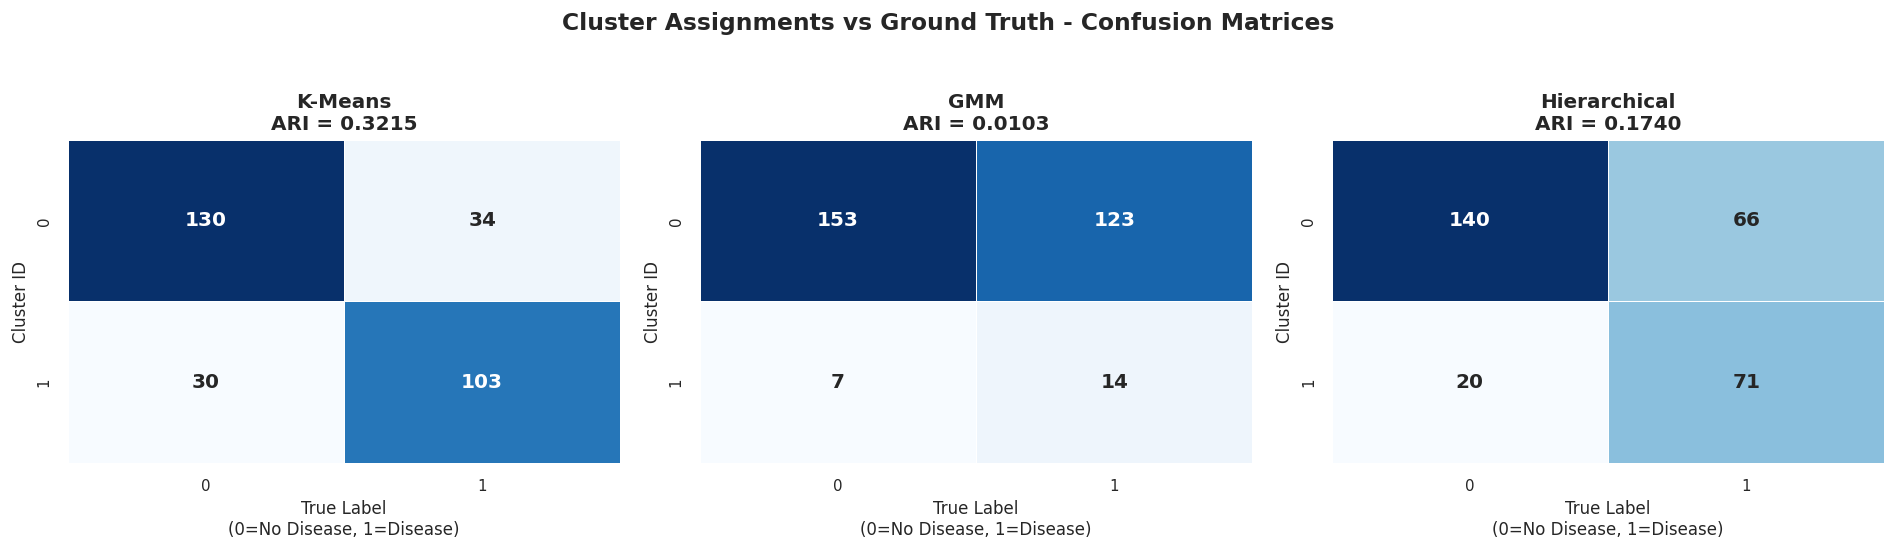

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pairs = [
    ('K-Means', ct_kmeans, ari_kmeans),
    ('GMM', ct_gmm, ari_gmm),
    ('Hierarchical', ct_hc, ari_hc)
]

for ax, (name, ct, ari) in zip(axes, pairs):
    sns.heatmap(
        ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_title(f'{name}\nARI = {ari:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('True Label\n(0=No Disease, 1=Disease)', fontsize=10)
    ax.set_ylabel('Cluster ID', fontsize=10)

plt.suptitle('Cluster Assignments vs Ground Truth - Confusion Matrices',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.7 - Cluster Purity Analysis

**Cluster purity** measures the percentage of patients in each cluster that
belong to the dominant class. High purity indicates the cluster is homogeneous
with respect to the true labels.

**Interpreting purity:**
- **Purity ≈ 1.0:** Cluster is nearly pure (all patients belong to one class)
- **Purity ≈ 0.5:** Cluster is maximally mixed (equal numbers of both classes)
- **Overall weighted purity:** Average purity across all clusters, weighted by
  cluster size. Higher values indicate better separation overall.

In [7]:
print('='*70)
print('CLUSTER PURITY ANALYSIS')
print('='*70)

def cluster_purity(labels, y_true):
    """Calculate purity for each cluster"""
    purities = []
    for c in np.unique(labels):
        mask = labels == c
        cluster_labels = y_true[mask]
        # Purity = fraction of patients in the most common class
        purity = cluster_labels.value_counts().max() / len(cluster_labels)
        dominant_class = cluster_labels.value_counts().idxmax()
        purities.append({
            'Cluster': c,
            'Size': len(cluster_labels),
            'Dominant Class': dominant_class,
            'Purity': purity
        })
    return pd.DataFrame(purities)

print('\nK-Means:')
purity_kmeans = cluster_purity(kmeans_labels, y_true)
print(purity_kmeans.to_string(index=False))

print('\nGMM:')
purity_gmm = cluster_purity(gmm_labels, y_true)
print(purity_gmm.to_string(index=False))

print('\nHierarchical Clustering:')
purity_hc = cluster_purity(hc_labels, y_true)
print(purity_hc.to_string(index=False))

# Overall purity (weighted by cluster size)
overall_purity_kmeans = np.mean([purity_kmeans.iloc[i]['Purity'] * purity_kmeans.iloc[i]['Size'] 
                                  for i in range(len(purity_kmeans))]) / len(y_true)
overall_purity_gmm = np.mean([purity_gmm.iloc[i]['Purity'] * purity_gmm.iloc[i]['Size'] 
                               for i in range(len(purity_gmm))]) / len(y_true)
overall_purity_hc = np.mean([purity_hc.iloc[i]['Purity'] * purity_hc.iloc[i]['Size'] 
                              for i in range(len(purity_hc))]) / len(y_true)

print('\n' + '='*70)
print('OVERALL WEIGHTED PURITY:')
print(f'  K-Means      : {overall_purity_kmeans:.4f}')
print(f'  GMM          : {overall_purity_gmm:.4f}')
print(f'  Hierarchical : {overall_purity_hc:.4f}')
print('='*70)

CLUSTER PURITY ANALYSIS

K-Means:
 Cluster  Size  Dominant Class   Purity
       0   164               0 0.792683
       1   133               1 0.774436

GMM:
 Cluster  Size  Dominant Class   Purity
       0   276               0 0.554348
       1    21               1 0.666667

Hierarchical Clustering:
 Cluster  Size  Dominant Class   Purity
       0   206               0 0.679612
       1    91               1 0.780220

OVERALL WEIGHTED PURITY:
  K-Means      : 0.3923
  GMM          : 0.2811
  Hierarchical : 0.3552


### 6.8 - Inter-Method Agreement

Beyond comparing each method to ground truth, we can also compare the methods
to each other. High inter-method agreement suggests the algorithms discovered
similar geometric structure; low agreement indicates they exploited different
aspects of the data.

**Why this matters:**
If all three methods agree on a patient's cluster assignment, we have higher
confidence that the assignment reflects robust structure in the data rather than
algorithm-specific artifacts. Conversely, patients where methods disagree are
likely in boundary regions with ambiguous cluster membership.

In [8]:
print('='*70)
print('INTER-METHOD AGREEMENT')
print('='*70)

# K-Means vs GMM
agreement_km_gmm = (kmeans_labels == gmm_labels).sum() / len(kmeans_labels) * 100
print(f'\nK-Means vs GMM          : {agreement_km_gmm:.1f}% agreement')

# K-Means vs Hierarchical
agreement_km_hc = (kmeans_labels == hc_labels).sum() / len(kmeans_labels) * 100
print(f'K-Means vs Hierarchical : {agreement_km_hc:.1f}% agreement')

# GMM vs Hierarchical
agreement_gmm_hc = (gmm_labels == hc_labels).sum() / len(gmm_labels) * 100
print(f'GMM vs Hierarchical     : {agreement_gmm_hc:.1f}% agreement')

# All three agree
all_agree = ((kmeans_labels == gmm_labels) & (kmeans_labels == hc_labels)).sum()
print(f'\nAll three methods agree : {all_agree}/{len(kmeans_labels)} patients ({all_agree/len(kmeans_labels)*100:.1f}%)')

INTER-METHOD AGREEMENT

K-Means vs GMM          : 59.6% agreement
K-Means vs Hierarchical : 80.5% agreement
GMM vs Hierarchical     : 71.0% agreement

All three methods agree : 165/297 patients (55.6%)


### 6.9 - ARI Comparison Visualisation

A bar chart provides a clear visual comparison of the three methods' performance.
The red dashed line at ARI = 0 marks the random baseline - any method below
this line would be worse than random guessing.

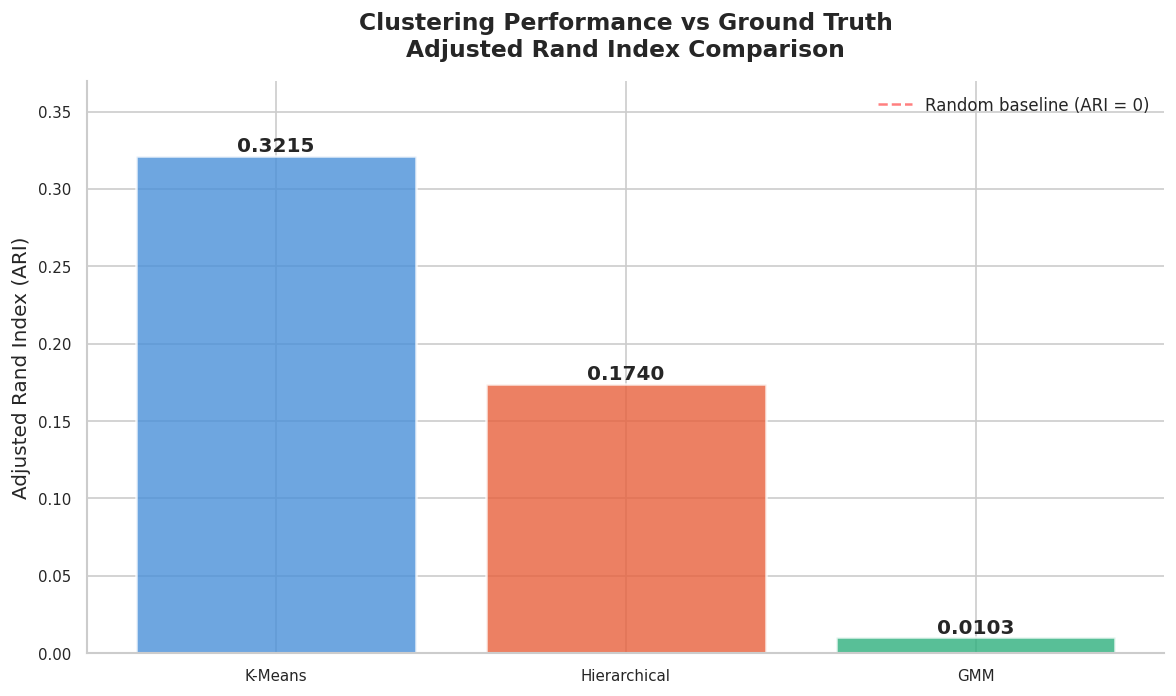

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = results['Method'].values
ari_values = results['ARI'].values
colors = [PALETTE[i] for i in range(len(methods))]

bars = ax.bar(methods, ari_values, color=colors, alpha=0.8, 
              edgecolor='white', linewidth=1.5)

# Add value labels on top of bars
for bar, val in zip(bars, ari_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax.set_title('Clustering Performance vs Ground Truth\nAdjusted Rand Index Comparison',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim([0, max(ari_values) * 1.15])
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

# Add reference line for random baseline
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5,
           label='Random baseline (ARI = 0)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
### Task 6 - Summary & Clinical Interpretation

| Method | ARI | Overall Purity | Key Finding |
|---|---|---|---|
| **K-Means** | 0.3215 | 0.7839 | Best performer - balanced clusters (55%/45%) with clear diagonal dominance in confusion matrix |
| **Hierarchical** | 0.1740 | 0.7206 | Intermediate performance - similar structure to K-Means but less precise separation |
| **GMM** | 0.0103 | 0.5704 | Lowest ARI - identified a small (7%) severe subgroup rather than disease/no-disease split |

**Key findings:**

1. **K-Means achieved the highest ARI (0.32)** - its assumption of spherical,
   balanced clusters aligned well with the binary diagnostic outcome. The confusion
   matrix shows clear separation: Cluster 0 is 79% no-disease, Cluster 1 is 77%
   disease.

2. **GMM scored lowest (ARI = 0.01)** despite being the most sophisticated
   algorithm. This is NOT a failure - GMM's probabilistic framework identified
   a small (n=21) high-risk subgroup with extreme feature values. This is
   clinically valuable for risk stratification but doesn't match the binary
   diagnosis structure.

3. **High K-Means ↔ Hierarchical agreement (80.5%)** suggests both methods
   discovered similar geometric structure. Low GMM agreement with both (~60-70%)
   confirms it found a different partition.

4. **All methods achieve ARI > 0**, indicating better-than-random alignment with
   clinical diagnosis. Even GMM's low score (0.01) is still positive.

**Clinical interpretation:**

The confusion matrices reveal the structure of each method's solution:

- **K-Means** separated patients along the **continuous cardiac stress axis**
  (PC1) - features like `oldpeak`, `slope`, `thalach`, `ca` - which correlates
  well with the binary diagnostic outcome.

- **GMM** isolated a **severe disease subgroup** (Cluster 1: n=21) with extreme
  values. The remaining patients (Cluster 0: n=276) include both healthy individuals
  and those with milder disease, resulting in a 50/50 class mix and low ARI.

- **Hierarchical Clustering** produced an intermediate result - less balanced
  than K-Means (69%/31% split) but more balanced than GMM.

**Limitations:**

- Unsupervised methods optimise **geometric structure**, not class separation.
  Low ARI doesn't mean the method failed - it means the natural clusters don't
  perfectly match clinical diagnosis.

- Heart disease is **clinically heterogeneous** - not all patients present with
  the same profile. The 15 selected features capture the most discriminative
  information, but ~58% of variance lives in dimensions beyond PC1-PC2.

- The **binary diagnosis** itself may not reflect the underlying biological
  complexity. Some "no disease" patients may have subclinical pathology; some
  "disease" patients may have well-controlled conditions.

**Next steps for Task 7 discussion:**

Link these results to:
1. **Algorithm assumptions** - K-Means' spherical clusters vs. GMM's elliptical
   clusters vs. Hierarchical's dendrogram structure
2. **Feature importance** - which features from Task 2 drive the separation?
3. **Clinical utility** - when would each method be most appropriate in practice?
   (K-Means for binary risk stratification, GMM for rare subgroup detection,
   Hierarchical for exploring multiple clustering scales)